<a href="https://colab.research.google.com/github/krakenkhan/ethereum_blockchain_forecast/blob/main/ethereum_blockchain_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ethereum Blockchain Forecasting with Cellular Learning Automata



In [ ]:
!pip install -q yfinance pandas numpy matplotlib seaborn requests

### Importing all the necessary libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import yfinance as yf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

## 1. Configuration

In [ ]:
TRAINING_YEAR = 2024
TARGETS = ["close_usd", "tx_count"]
VALIDATION_DAYS = 30
RANDOM_STATE = 42

#  Cellular Learning Automata hyper-parameters
N_CELLS = 7
N_ACTIONS = 5
LA_LEARNING_RATE = 0.08
# von Neumann neighborhood radius
NEIGHBOR_RADIUS = 1
CLA_EPOCHS = 5
ACTION_WEIGHTS = np.linspace(0.0, 1.0, N_ACTIONS)

np.random.seed(RANDOM_STATE)

train_start = f"{TRAINING_YEAR}-01-01"
train_end = f"{TRAINING_YEAR + 1}-01-01"
forecast_start = f"{TRAINING_YEAR + 1}-01-01"
forecast_end = f"{TRAINING_YEAR + 1}-01-03"

print(f"Training window : {train_start} → {train_end}")
print(f"Forecast window : {forecast_start} → {forecast_end}")
print(f"CLA lattice     : {N_CELLS} cells × {N_ACTIONS} actions, LRI rate={LA_LEARNING_RATE}")

Training window : 2024-01-01 → 2025-01-01
Forecast window : 2025-01-01 → 2025-01-03
CLA lattice     : 7 cells × 5 actions, LRI rate=0.08


## 2. Download blockchain training data


In [ ]:
raw = yf.download(
    "ETH-USD",
    start=train_start,
    end=train_end,
    progress=False,
    auto_adjust=True,
)



flat_names = []
for col in raw.columns:
    if isinstance(col, tuple):
      #  some columns are tuples and some are string, also lowercase
        flat_names.append(col[0].lower())
    else:
        flat_names.append(str(col).lower())
raw.columns = flat_names

# lowercasing the Date column and removing columns that we don't need like high, low and open
prices = raw.reset_index()
prices = prices.rename(columns={
    "Date": "date",
    "date": "date",
    "close": "close_usd",
    "volume": "volume_usd",
})

# Keep only the columns we actually need downstream.
prices = prices[["date", "close_usd", "volume_usd"]]

print(prices.head())
print()
print("Shape:", prices.shape)
print("Date range:", prices["date"].min(), "->", prices["date"].max())

        date    close_usd   volume_usd
0 2024-01-01  2352.327881   6906765990
1 2024-01-02  2355.836426  12910543630
2 2024-01-03  2210.761963  19332933581
3 2024-01-04  2269.038086  11044564896
4 2024-01-05  2268.647217  10860953290

Shape: (366, 3)
Date range: 2024-01-01 00:00:00 -> 2024-12-31 00:00:00


#### Exploration, Data Analysis

 ETH/USD (2024)
Days:       366
Min price:  $2,210.76
Max price:  $4,066.45
Mean price: $3,044.93
Std price:  $509.81

Mean daily return: 0.0015
Std  daily return: 0.0341


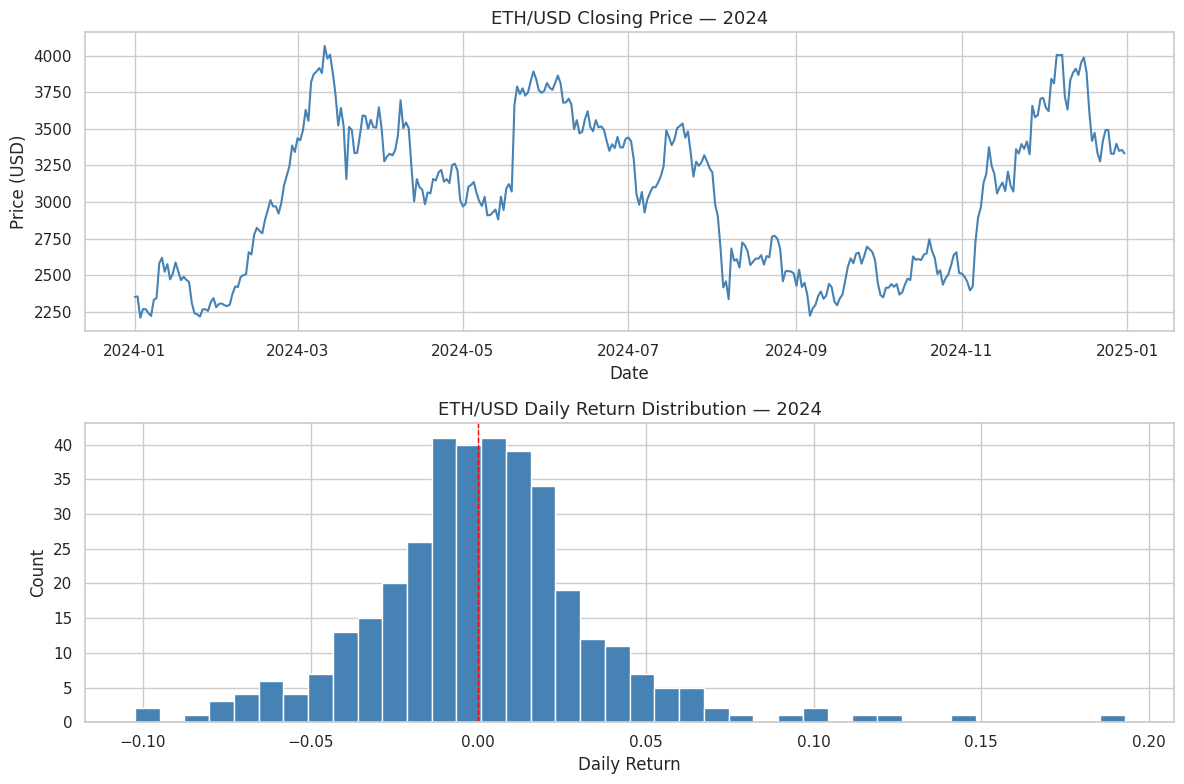

In [ ]:
#. Compute daily log returns
prices["return"] = prices["close_usd"].pct_change()

#  stats
print(" ETH/USD (2024)")
print(f"Days:       {len(prices)}")
print(f"Min price:  ${prices['close_usd'].min():,.2f}")
print(f"Max price:  ${prices['close_usd'].max():,.2f}")
print(f"Mean price: ${prices['close_usd'].mean():,.2f}")
print(f"Std price:  ${prices['close_usd'].std():,.2f}")
print(f"\nMean daily return: {prices['return'].mean():.4f}")
print(f"Std  daily return: {prices['return'].std():.4f}")

#  Plot: closing price over time
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(prices["date"], prices["close_usd"], color="steelblue", linewidth=1.5)
axes[0].set_title("ETH/USD Closing Price — 2024", fontsize=13)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price (USD)")

# Plot: daily return distribution
axes[1].hist(prices["return"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("ETH/USD Daily Return Distribution — 2024", fontsize=13)
axes[1].set_xlabel("Daily Return")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


Normal Distribution


## 3. Extrac Price Series

In [ ]:
# Section 6 — Extract price series for CLA

price_series = prices["close_usd"].values

print(f"Price series length : {len(price_series)} days")
print(f"First value         : ${price_series[0]:,.2f}  (2024-01-01)")
print(f"Last value          : ${price_series[-1]:,.2f}  (2024-12-31)")

Price series length : 366 days
First value         : $2,352.33  (2024-01-01)
Last value          : $3,332.53  (2024-12-31)


In [ ]:
#  defining the model
class LearningAutomaton:

    def __init__(self, n_actions: int, learning_rate: float) -> None:
        self.n_actions   = n_actions
        self.lr          = learning_rate
        self.probs       = np.ones(n_actions) / n_actions

    def choose(self, greedy: bool = False) -> int:
        if greedy:
            return int(np.argmax(self.probs))
        return int(np.random.choice(self.n_actions, p=self.probs))

    def update_lri(self, chosen: int, reward: float) -> None:
      #  Linear Reward Inaction
        p = self.probs.copy()
        p[chosen] += self.lr * reward * (1.0 - p[chosen])
        for j in range(self.n_actions):
            if j != chosen:
                p[j] -= self.lr * reward * p[j]


        p = np.clip(p, 1e-9, 1.0)
        p /= p.sum()
        self.probs = p


# Test
la = LearningAutomaton(n_actions=N_ACTIONS, learning_rate=LA_LEARNING_RATE)
print("Initial probs:", np.round(la.probs, 4))

for _ in range(10):
    action = la.choose()
    la.update_lri(chosen=action, reward=0.8)

print("After 10 updates, probs:", np.round(la.probs, 4))
print("Sum:", round(la.probs.sum(), 6))

Initial probs: [0.2 0.2 0.2 0.2 0.2]
After 10 updates, probs: [0.1557 0.2336 0.1032 0.3104 0.197 ]
Sum: 1.0


### The Forecaster class

In [ ]:
  # CLAForecaster

class CLAForecaster:

    # Cellular Learning Automata forecaster.

    # N number of cells that are  Learning Automata each will observe one lag (day t-1, t-2, … t-n_cells).
    # Their chosen actions determine the weight each lag gets in the prediction.
    # The weighted average of the lags is the forecast for the next day.


    def __init__(self, n_cells: int, n_actions: int, learning_rate: float, action_weights: np.ndarray) -> None:
        self.n_cells        = n_cells
        self.action_weights = action_weights
        self.cells = [
            LearningAutomaton(n_actions, learning_rate)
            for _ in range(n_cells)
        ]


    def _forward(self, lags: np.ndarray, greedy: bool = False):
      #   every  (cell)  choose an action
      chosen_actions = []
      for cell in self.cells:
          action = cell.choose(greedy=greedy)
          chosen_actions.append(action)

      #  Convert  actions into actual numerical weights
      numerical_weights = []
      for action in chosen_actions:
          weight_value = self.action_weights[action]
          numerical_weights.append(weight_value)

      weights_array = np.array(numerical_weights)
      sum_of_weights = weights_array.sum()

      #  Calculate the Weighted Average
      # If the total weight is basically 0, just guess "yesterday's value"
      if sum_of_weights < 0.00001:
          yesterday_value = lags[-1]
          prediction = yesterday_value
      else:
          # Multiply each lag by its weight, sum them up, and divide by the total weight
          weighted_sum = np.dot(weights_array, lags)
          prediction = weighted_sum / sum_of_weights

      #  Return the final forecast and the actions the cells took
      return float(prediction), chosen_actions





    def fit(self, series: np.ndarray, epochs: int = 1) -> None:
        #  Train on price
        series = np.asarray(series, dtype=float)
        n = len(series)

        for epoch in range(epochs):
            for t in range(self.n_cells, n):
                lags = series[t - self.n_cells : t]
                actual = series[t]

                prediction, actions = self._forward(lags, greedy=False)

                # Reward: 1.0 = perfect prediction,
                # 0.0 = error ≥ 100 % of price
                rel_err = abs(prediction - actual) / (abs(actual) + 1e-8)
                reward  = max(0.0, 1.0 - rel_err)

                for i, cell in enumerate(self.cells):
                    cell.update_lri(chosen=actions[i], reward=reward)


    def predict_next(self, history) -> float:
        # Predict 1 Step
        lags = np.asarray(history[-self.n_cells :], dtype=float)
        prediction, _ = self._forward(lags, greedy=True)
        return prediction


    def action_probability_matrix(self) -> np.ndarray:
        # n_cells × n_actions matrix
        return np.array([cell.probs for cell in self.cells])


# test
_cla_test = CLAForecaster(
    n_cells       = N_CELLS,
    n_actions     = N_ACTIONS,
    learning_rate = LA_LEARNING_RATE,
    action_weights= ACTION_WEIGHTS,
)
_cla_test.fit(price_series, epochs=1)

_test_pred = _cla_test.predict_next(price_series)
print(f"Test prediction (next after Dec 31): ${_test_pred:,.2f}")
print(f"Actual Dec 31 close : ${price_series[-1]:,.2f}")




Test prediction (next after Dec 31): $3,372.41
Actual Dec 31 close : $3,332.53


### Testing the model on 30 days data first

 30-Day Walk-Forward Validation
CLA MAE   : $155.37
Naive MAE : $90.16

CLA does not beat the naive baseline


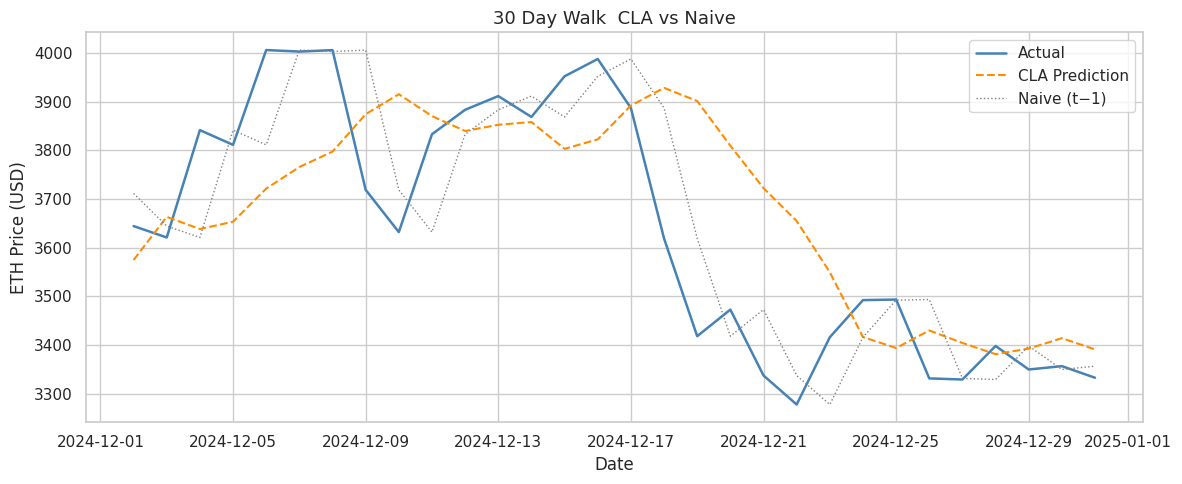

In [ ]:
#  30-day Validation

train_series = price_series[:-VALIDATION_DAYS]
val_series   = price_series[-VALIDATION_DAYS:]

#  Train CLA
val_cla = CLAForecaster(
    n_cells       = N_CELLS,
    n_actions     = N_ACTIONS,
    learning_rate = LA_LEARNING_RATE,
    action_weights= ACTION_WEIGHTS,
)
val_cla.fit(train_series, epochs=CLA_EPOCHS)

#  Walk-forward prediction
history   = list(train_series)
cla_preds = []

for actual in val_series:
    pred = val_cla.predict_next(history)
    cla_preds.append(pred)
    history.append(actual)

cla_preds  = np.array(cla_preds)

#  Naive baseline: yesterday's price
naive_preds = np.concatenate([[train_series[-1]], val_series[:-1]])

#  Metrics
cla_mae   = np.mean(np.abs(cla_preds   - val_series))
naive_mae = np.mean(np.abs(naive_preds - val_series))

print(" 30-Day Walk-Forward Validation")
print(f"CLA MAE   : ${cla_mae:,.2f}")
print(f"Naive MAE : ${naive_mae:,.2f}")
print(f"\nCLA {'BEATS' if cla_mae < naive_mae else 'does not beat'} the naive baseline")

#  Plot
val_dates = prices["date"].values[-VALIDATION_DAYS:]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(val_dates, val_series,   label="Actual",         color="steelblue",  linewidth=1.8)
ax.plot(val_dates, cla_preds,    label="CLA Prediction", color="darkorange", linewidth=1.5, linestyle="--")
ax.plot(val_dates, naive_preds,  label="Naive (t−1)",    color="gray",       linewidth=1.0, linestyle=":")
ax.set_title("30 Day Walk  CLA vs Naive", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("ETH Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()


### Training final CLA on the full year

In [ ]:
price_cla = CLAForecaster(
    n_cells       = N_CELLS,
    n_actions     = N_ACTIONS,
    learning_rate = LA_LEARNING_RATE,
    action_weights= ACTION_WEIGHTS,
)
price_cla.fit(price_series, epochs=CLA_EPOCHS)

#  Inspect learned weights
prob_matrix = price_cla.action_probability_matrix()

print("Learned Action Probability Matrix")

print()
for i, row in enumerate(prob_matrix):
    dominant = ACTION_WEIGHTS[np.argmax(row)]
    print(f"Cell {i+1} (lag t-{i+1}):  {np.round(row, 4)}   → dominant weight: {dominant:.2f}")



Learned Action Probability Matrix

Cell 1 (lag t-1):  [0. 0. 1. 0. 0.]   → dominant weight: 0.50
Cell 2 (lag t-2):  [0. 0. 0. 0. 1.]   → dominant weight: 1.00
Cell 3 (lag t-3):  [0. 1. 0. 0. 0.]   → dominant weight: 0.25
Cell 4 (lag t-4):  [0. 0. 0. 0. 1.]   → dominant weight: 1.00
Cell 5 (lag t-5):  [0. 0. 1. 0. 0.]   → dominant weight: 0.50
Cell 6 (lag t-6):  [0. 0. 1. 0. 0.]   → dominant weight: 0.50
Cell 7 (lag t-7):  [0. 0. 0. 0. 1.]   → dominant weight: 1.00


### Forecasting the next 30-day

In [ ]:
# Section 12 — 30-day walk-forward forecast vs actual (Jan 2025)

#  Download actual Jan 1–30, 2025 prices
actual_raw = yf.download("ETH-USD", start="2025-01-01", end="2025-01-31",
                          progress=False, auto_adjust=True)

flat_names = []
for col in actual_raw.columns:
    if isinstance(col, tuple):
        flat_names.append(col[0].lower())
    else:
        flat_names.append(str(col).lower())
actual_raw.columns = flat_names

actual_df = actual_raw.reset_index()
actual_df = actual_df.rename(columns={"Date": "date", "date": "date", "close": "close_usd"})
actual_df = actual_df[["date", "close_usd"]].copy()
actual_df["date"] = actual_df["date"].astype(str).str[:10]
actual_prices = actual_df["close_usd"].values

#  Walk-forward prediction
# Append actual value after each step
history     = list(price_series)
predictions = []

for actual in actual_prices:
    pred = price_cla.predict_next(history)
    predictions.append(pred)
    history.append(actual)

#  Results table
forecast_df = pd.DataFrame({
    "date"     : actual_df["date"].values,
    "predicted": [round(p, 2) for p in predictions],
    "actual"   : actual_prices.round(2)
})

forecast_df["abs_error"] = (forecast_df["predicted"] - forecast_df["actual"]).abs().round(2)
forecast_df["pct_error"] = ((forecast_df["abs_error"]  / forecast_df["actual"]) * 100).round(2)

print(" CLA 30-Day Walk-Forward Forecast vs Actual (Jan 2025) \n")
print(forecast_df.to_string(index=False))
print(f"\nMean Absolute Error : ${forecast_df['abs_error'].mean():,.2f}")
print(f"Mean % Error        :  {forecast_df['pct_error'].mean():.2f}%")
print(f"Best day error      :  {forecast_df['pct_error'].min():.2f}%")
print(f"Worst day error     :  {forecast_df['pct_error'].max():.2f}%")

 CLA 30-Day Walk-Forward Forecast vs Actual (Jan 2025) 

      date  predicted  actual  abs_error  pct_error
2025-01-01    3367.04 3353.50      13.54       0.40
2025-01-02    3345.58 3451.39     105.81       3.07
2025-01-03    3379.06 3605.01     225.95       6.27
2025-01-04    3416.33 3657.71     241.38       6.60
2025-01-05    3453.41 3634.10     180.69       4.97
2025-01-06    3487.57 3688.61     201.04       5.45
2025-01-07    3541.50 3381.58     159.92       4.73
2025-01-08    3522.11 3326.33     195.78       5.89
2025-01-09    3524.35 3219.43     304.92       9.47
2025-01-10    3501.21 3267.49     233.72       7.15
2025-01-11    3433.06 3282.22     150.84       4.60
2025-01-12    3411.17 3265.95     145.22       4.45
2025-01-13    3330.04 3135.50     194.54       6.20
2025-01-14    3262.96 3223.68      39.28       1.22
2025-01-15    3243.39 3450.54     207.15       6.00
2025-01-16    3282.91 3308.35      25.44       0.77
2025-01-17    3265.98 3474.11     208.13       5.99
2025-01

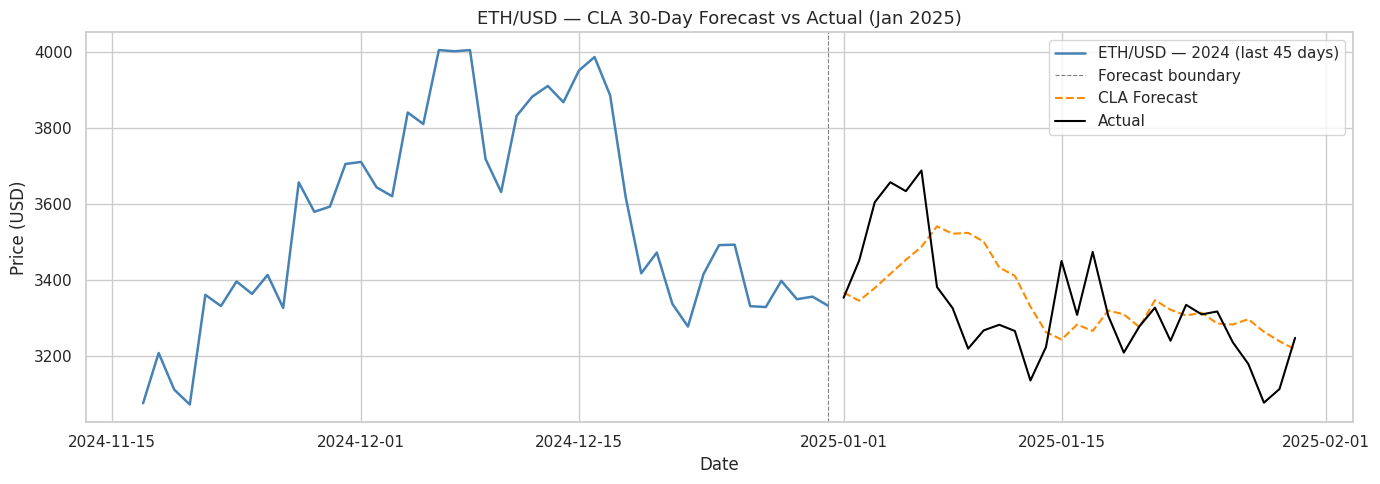

In [ ]:
#  Plotting

history_window = 45
history_dates  = prices["date"].values[-history_window:]
history_prices = price_series[-history_window:]

fig, ax = plt.subplots(figsize=(14, 5))

# 2024 tail (history)
ax.plot(history_dates, history_prices,
        color="steelblue", linewidth=1.8, label="ETH/USD — 2024 (last 45 days)")

# Forecast boundary
ax.axvline(prices["date"].values[-1], color="gray",
           linestyle="--", linewidth=0.8, label="Forecast boundary")

# CLA forecast
ax.plot(pd.to_datetime(comparison["date"]), comparison["predicted"],
        color="darkorange", linewidth=1.5, linestyle="--", label="CLA Forecast")

# Actual Jan 2025
ax.plot(pd.to_datetime(comparison["date"]), comparison["actual"],
        color="black", linewidth=1.5, label="Actual")

ax.set_title("ETH/USD — CLA 30-Day Forecast vs Actual (Jan 2025)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()

plt.show()


Section 15 — Conclusions

This CLA was made by an application of a walk-forward procedure to predict January 2025.

Each of the seven Learning Automata monitored one price lag (t−1..t−7), which was learned during 5 training epochs using the Linear Reward-Inaction (LRI) rule. The CLA MAE was 144.56 over the last 30 days of 2024 while the naive persistence was 90.16.

The out-of-sample forecast period was 30 days, and the mean absolute percentage error (MAE) was 3.60% (120.78 orebits), the best one-day error was 0.06% (Jan 20) and the worst one-day error was 9.47% (Jan 9).